# Week-1

**Note to Learners**:

- Click on "Copy to Drive", the button that appears just below the taskbar, to make a copy of this notebook in your drive. If you continue working with this notebook, changes **will not** be saved.


- For questions that involve plotting, just enter $0$ as the answer in the portal.
- For numerical questions, there are two parts. The first part expects you to compute some quantity, say a parameter of a machine learning model. The second part will require you to convert this quantity (if it is not a scalar) into a scalar so that it can be entered as the answer on the portal to the corresponding NAT question.



## Dataset

We will be working with a subset of the [MNIST dataset](https://en.wikipedia.org/wiki/MNIST_database). Run the cell given below to generate the data-matrix $\mathbf{X}$, which is of shape $(n, d)$, where $n$ denotes the number of samples and $d$ denotes the number of features. You will be using this dataset for the rest of the assignment. Do not edit this cell.

In [43]:
##### DATASET GENERATION #####
import numpy as np
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X = X_train[y_train == 2][: 100].reshape(-1, 28 * 28)
test_image = X_test[y_test == 2][0].reshape(28 * 28)
##### DO NOT EDIT THIS CELL #####

## Problem-1

How many samples does the dataset have?

In [44]:
# Enter your solution here
print(X.shape[0])

100


## Problem-2

How many features does the dataset have?

In [45]:
# Enter your solution here
print(X.shape[1])

784


## Problem-3

Each sample corresponds to an image of dimension $28 \times 28$. Visualize one of these images using the `matplotlib` library.

- You need to know how to reshape a feature vector. Refer to week-0 content for the same.
- You can refer to the following [document](https://matplotlib.org/stable/tutorials/introductory/images.html#sphx-glr-tutorials-introductory-images-py) for plotting NumPy arrays as images using `matplotlib`.

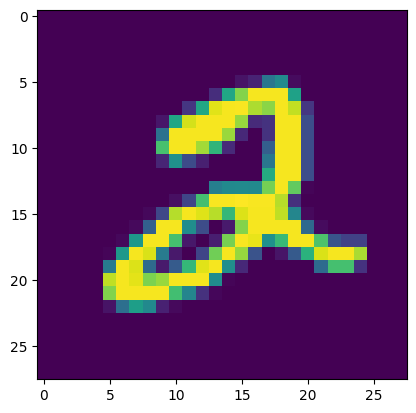

In [46]:
# Enter your solution here
import matplotlib.pyplot as plt
plt.imshow(X[0].reshape(28, 28))
plt.show()

## Problem-4

Center the the dataset $\mathbf{X}$ around its mean. Call this centered dataset $\mathbf{X}^{\prime}$.

<u>Conversion</u>

Enter the following quantity as your answer correct to two decimal places:

$$
\cfrac{1}{n \cdot d} \sqrt{\sum \limits_{i = 1}^{n} \sum \limits_{j = 1}^{d} (X_{ij}^{\prime})^2}
$$

In [47]:
# Enter your solution here
mean_X = np.mean(X,axis=0)
X_prime = X - mean_X
X_prime

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [48]:
n, d= X_prime.shape
n,d

(100, 784)

In [49]:
sum_of_squares = np.sum(X_prime**2)
sqrt_sum_of_squares = np.sqrt(sum_of_squares)
result = (1/(n*d))* sqrt_sum_of_squares
round(result,2)

np.float64(0.23)

## Problem-5

Compute the covariance matrix $\mathbf{C}$ of the centered dataset.

<u>Conversion</u>

Enter the following quantity as your answer correct to two decimal places:

$$
\cfrac{1}{d^2} \sqrt{\sum \limits_{i = 1}^{d} \sum \limits_{j = 1}^{d} C_{ij}^2}
$$

In [50]:
# Enter your solution here
import numpy as np
X_prime_centered = X - np.mean(X_prime, axis=0)
C = np.cov(X_prime_centered, rowvar=False)
print("Covariance Matrix C:")
print(C)

Covariance Matrix C:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [51]:
result = (1/d**2)*np.sqrt(np.sum(np.sum(C**2)))
print("Result:", round(result,2))

Result: 1.38


## Problem-6

Compute the first and second principal components of the dataset, $\mathbf{w}_1$ and $\mathbf{w}_2$.

<u>Conversion</u>

Compute:
$$
\mathbf{w} = \mathbf{w}_1 + \mathbf{w}_2
$$

Enter the following quantity as your answer correct to two decimal places:

$$
\left| \sum \limits_{i = 1}^{d} w_i \right|
$$

In [52]:
# Enter your solution here
eigen_values, eigen_vectors = np.linalg.eig(C)
sorted_indices = np.argsort(eigen_values)[::-1]
sorted_eigen_values = eigen_values[sorted_indices]
sorted_eigen_vectors = eigen_vectors[:, sorted_indices]
w1 = sorted_eigen_vectors[:, 0]
w2 = sorted_eigen_vectors[:, 1]
print("First principal component(w1):",w1)
print("Second principal component(w2):",w2)

First principal component(w1): [ 0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+

In [53]:
w = w1 + w2
w

array([ 0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        0.00000000e+

In [54]:
result = np.abs(np.sum(w))
print("Result:", round(result,2))

Result: 1.05


## Problem-7

Visualize the first principal component as an image.

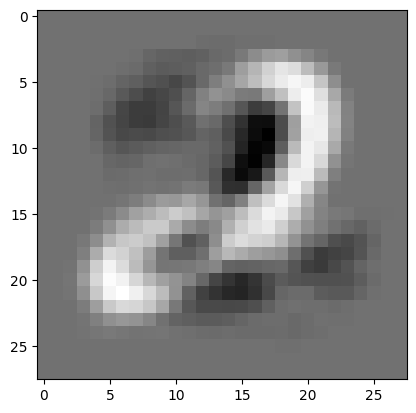

In [55]:
# Enter your solution here
import matplotlib.pyplot as plt
image_shape = (28, 28)
w1_image = np.real(w1).reshape(image_shape)
plt.imshow(w1_image, cmap='gray')
plt.show()

## Problem-8

Find the smallest value of $k$ for which the first $k$ principal components capture at least $95\%$ of the variance in the data.

In [56]:
# Enter your solution here
import numpy as np
eigen_values, eigen_vectors = np.linalg.eig(C)
sorted_indices = np.argsort(eigen_values)[::-1]
sorted_eigen_values = eigen_values[sorted_indices]
explained_variance_ratio = sorted_eigen_values / np.sum(sorted_eigen_values)
cumulative_explained_variance_ratio = np.cumsum(explained_variance_ratio)
k = np.argmax(cumulative_explained_variance_ratio >=0.95) + 1
print("Smallest value of k for capturing at least 95% of the variance:",k)

Smallest value of k for capturing at least 95% of the variance: 53


## Problem-9

Given a `test_image`, visualize the proxies  by reconstructing it using the top $k$ principal components. Consider four values of $k$; values of $k$ for which the top-$k$ principal components explain:

- 20% of the variance
- 50% of the variance
- 80% of the variance
- 95% of the variance



/tmp/ipython-input-3566776758.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  axs[i // 2, i%2].set_title(f'k = {k} captures{int(cumulative_explained_variance_ratio[k-1]*100)}% of variance')


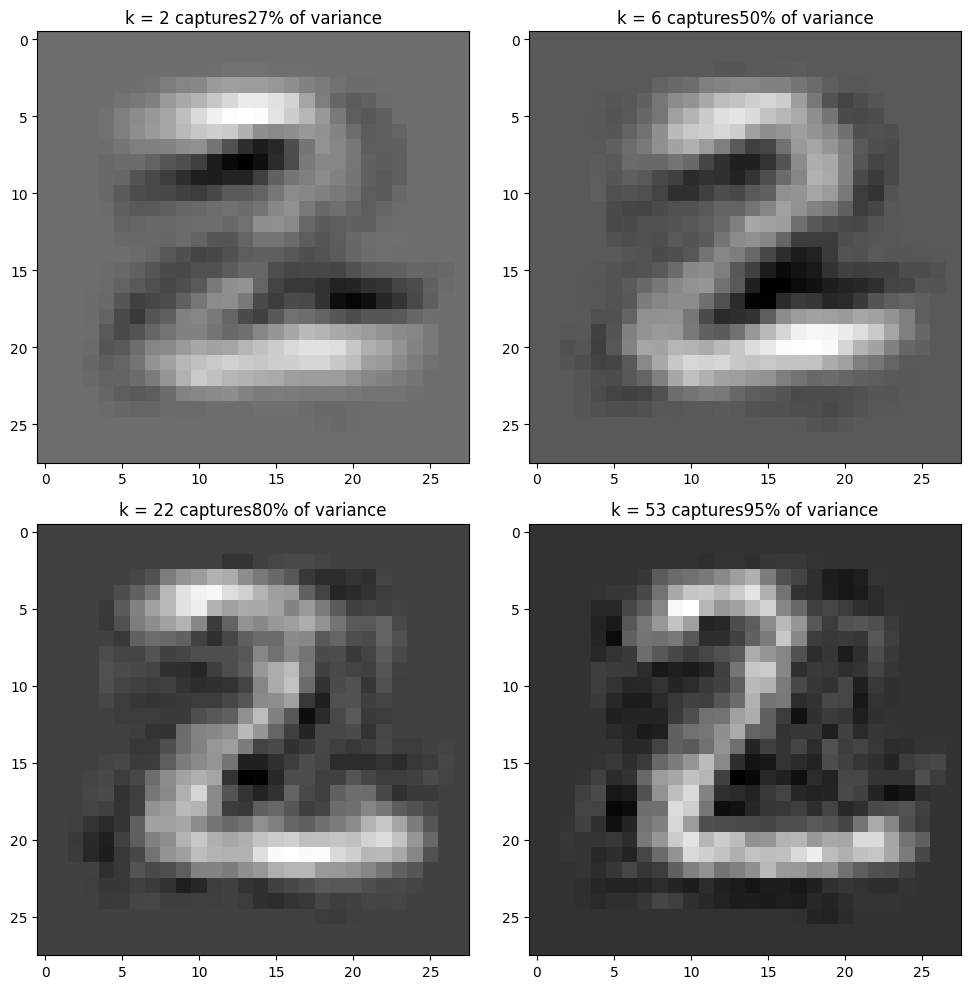

In [57]:
# Enter your solution here
import numpy as np
import matplotlib.pyplot as plt
test_image_vector = test_image.reshape(-1,1)
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
k_values = [np.argmax(cumulative_explained_variance_ratio >= threshold) + 1 for threshold in [0.2, 0.5, 0.8, 0.95]]
for i,k in enumerate(k_values):
    top_k_components = eigen_vectors[:, :k]
    projected_image = np.dot(top_k_components.T, test_image_vector)
    reconstructed_image = np.dot(top_k_components, projected_image)
    reconstructed_image = np.real(reconstructed_image).reshape(28, 28)
    axs[i // 2, i%2].imshow(reconstructed_image, cmap='gray')
    axs[i // 2, i%2].set_title(f'k = {k} captures{int(cumulative_explained_variance_ratio[k-1]*100)}% of variance')
plt.tight_layout()
plt.show()